### Implementation of video 2:
### "Building makemore Part 2: MLP"
*(https://youtu.be/TCH_1BHY58I?si=K-3LdgqGDGu-z3Be)*

In [20]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [21]:
words = open('../data/names.txt', 'r').read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [22]:
len(words)

32033

In [23]:
characters = sorted(list(set(''.join(words))))
s_to_i = {s:i+1 for i,s in enumerate(characters)}
s_to_i['.'] = 0
i_to_s = {i:s for s,i in s_to_i.items()}
print(i_to_s)


{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


In [24]:
# build dataset

block_size = 3
X, Y = [], []
# for w in words[:5]:
for w in words:

    # print(w)
    context = [0] * block_size
    for chr in w + '.':
        ix = s_to_i[chr]
        X.append(context)
        Y.append(ix)
        # print(''.join(i_to_s[i] for i in context), '---->', i_to_s[ix])
        context = context[1:] + [ix]
X = torch.tensor(X)
Y = torch.tensor(Y)

In [25]:
X.shape, X.dtype, Y.shape, Y.dtype

# output for first 5 words was:
# (torch.Size([32, 3]), torch.int64, torch.Size([32]), torch.int64)

(torch.Size([228146, 3]), torch.int64, torch.Size([228146]), torch.int64)

Train split, dev/validation split, test split

In [26]:
# converting above code to a function for later use
def build_dataset(words):
    block_size = 3
    X, Y = [], []
    # for w in words[:5]:
    for w in words:

        # print(w)
        context = [0] * block_size
        for chr in w + '.':
            ix = s_to_i[chr]
            X.append(context)
            Y.append(ix)
            # print(''.join(i_to_s[i] for i in context), '---->', i_to_s[ix])
            context = context[1:] + [ix]

    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print(X.shape, Y.shape)
    return X, Y

# shuffling
import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

# 80% training, 10% dev, 10% test
Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])

torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


In [27]:
C = torch.randn((27, 2))

onehot encoding example

In [28]:
# C[5]

In [29]:
# F.one_hot(torch.tensor([5]), num_classes=27)

resuming with makemore

In [30]:
emb = C[X]
emb.shape

torch.Size([228146, 3, 2])

In [31]:
W1 = torch.randn((6, 100))
b1 = torch.randn(100)

In [32]:
h = torch.tanh(emb.view(emb.shape[0], 6) @ W1 + b1)
h

tensor([[ 0.8034,  0.6192, -0.1447,  ..., -0.9829, -0.9900, -0.8641],
        [ 0.9998,  0.9299, -0.6390,  ..., -0.9999, -0.9997, -0.5163],
        [ 0.9974,  0.9422,  0.9145,  ..., -0.9863, -0.9586, -0.7508],
        ...,
        [-0.8949,  0.9998, -0.9952,  ..., -0.9381, -0.9977,  0.9596],
        [-0.0704, -0.9367,  0.9961,  ...,  1.0000,  0.9999,  0.9996],
        [-0.9826, -0.9779,  0.4964,  ..., -0.7209,  0.9964, -0.9998]])

In [33]:
h.shape

torch.Size([228146, 100])

In [34]:
W2 = torch.randn((100, 27))
b2 = torch.randn(27)

In [35]:
logits = h @ W2 + b2
logits.shape

torch.Size([228146, 27])

In [36]:
count = logits.exp()

In [37]:
prob = count / count.sum(1, keepdim=True)

prob.shape

torch.Size([228146, 27])

In [38]:
# loss = -prob[torch.arange(32), Y].log().mean()

# loss

 Since we now know how to calculate 'loss', so we use that logic

In [39]:
Xtr.shape, Ytr.shape

(torch.Size([182625, 3]), torch.Size([182625]))

In [40]:
# Initialize the parameters

g = torch.Generator().manual_seed(2147483647)
C = torch.randn((27, 10), generator=g)
W1 = torch.randn((30, 200), generator=g)
b1 = torch.randn(200, generator=g)
W2 = torch.randn((200, 27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2]

In [41]:
sum(p.nelement() for p in parameters)

11897

In [42]:
"""
By default, tensors created via torch.randn() do not track gradients or participate in the computation graph. 
This means loss.backward() can't propagate gradients back to them, leading to an error:
"RuntimeError: element 0 of tensors does not require grad and does not have a grad_fn"
"""

for p in parameters:
    p.requires_grad = True

In [43]:
# determining learning rate exponent
lre = torch.linspace(-3, 0, steps=1000)

lrs = 10**lre
# lrs

In [44]:
# determine lre: track stats
lri= []
lossi = []
stepi = []


In [45]:
for i in range(200000):

    # mini-batch construct
    ix = torch.randint(0, Xtr.shape[0], (32,))

    # forward pass
    emb = C[Xtr[ix]] # (32, 3, 2)
    h = torch.tanh(emb.view(-1, 30) @ W1 + b1) # (32, 200)
    logits = h @ W2 + b2 # (32, 27)

    # counts = logits.exp()
    # prob = counts / counts.sum(1, keepdim=True)
    # loss = -prob[torch.arange(32), Y].log().mean()
    
    # replace above logic (3 lines) with cross_entropy
    loss = F.cross_entropy(logits, Ytr[ix])
    # print(loss.item())

    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    #update
    # lr = lrs[i]
    lr = 0.1 if i < 100000 else 0.01

    for p in parameters:
        p.data += -lr * p.grad

    # # determine lre: track stats
    # lri.append(lre[i])
    lossi.append(loss.log10().item())
    stepi.append(i)

# print(loss.item())

# determine lre:plotting the learning rate exponent vs loss
# plt.plot(lri, lossi)
# plt.plot(stepi, lossi)

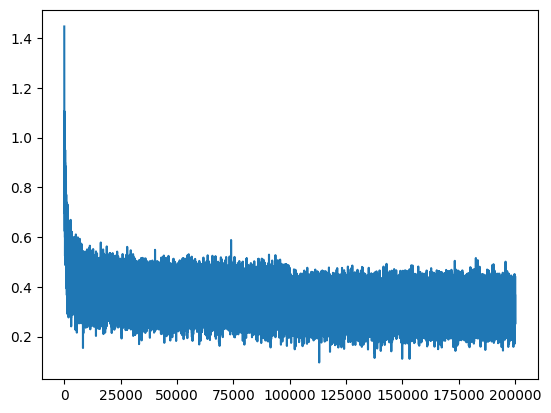

In [46]:
plt.plot(stepi, lossi)

For entire dataset:
learning rate = 0.1, we get: loss ~ 2.487
learning rate = 0.01, we get: loss ~ 2.57

In [47]:
# training dataset
emb = C[Xtr] # (32, 3, 2)
h = torch.tanh(emb.view(-1, 30) @ W1 + b1) # (32, 200)
logits = h @ W2 + b2 # (32, 27)
loss = F.cross_entropy(logits, Ytr)
loss

tensor(2.1253, grad_fn=<NllLossBackward0>)

In [48]:
# validation dataset
emb = C[Xdev] # (32, 3, 2)
h = torch.tanh(emb.view(-1, 30) @ W1 + b1) # (32, 200)
logits = h @ W2 + b2 # (32, 27)
loss = F.cross_entropy(logits, Ydev)
loss

tensor(2.1650, grad_fn=<NllLossBackward0>)

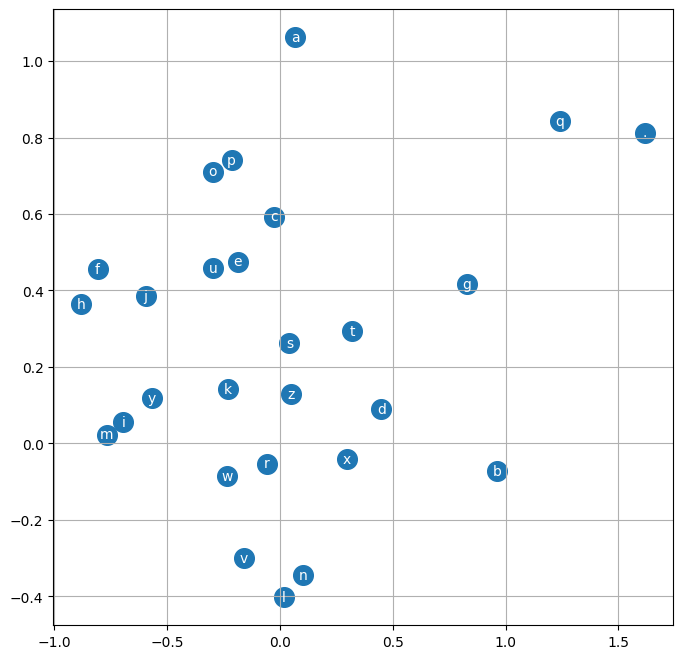

In [49]:
plt.figure(figsize=(8,8))
plt.scatter(C[:,0].data, C[:,1].data, s=200)
for i in range (C.shape[0]):
    plt.text(C[i,0].item(), C[i,1].item(), i_to_s[i], ha='center', va='center', color='white')
plt.grid('minor')

In [50]:
# sample from the model
g = torch.Generator().manual_seed(2147483647)

for _ in range(20):
    out = []
    context = [0] * block_size
    while True:
        emb = C[torch.tensor([context])]
        h = torch.tanh(emb.view(1, -1) @ W1 + b1) 
        logits = h @ W2 + b2 
        probs = F.softmax(logits, dim=1)
        ix = torch.multinomial(probs, num_samples=1, generator=g).item()
        context = context[1:] + [ix]
        out.append(ix)
        if ix == 0:
            break
        
    print(''.join(i_to_s[i] for i in out))

dex.
maleah.
makilah.
tyha.
malissana.
nylandrik.
tar.
samiyah.
javer.
gotai.
molie.
lavo.
keyten.
jen.
emia.
sade.
enkamerry.
fols.
milliven.
tahlyn.
